# 🍔 QuickBite — Know Your Diners
Segmentation (K-Means) · Market-basket analysis (Apriori) · Reorder prediction (classification) · Dashboard models

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from mlxtend.frequent_patterns import apriori, association_rules
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)

diners = pd.read_csv('diners.csv'); orders = pd.read_csv('orders.csv')
print(diners.shape, orders.shape, '| missing values:', diners.isna().sum().sum() + orders.isna().sum().sum())
print('Baskets:', orders.order_id.nunique(), '| Diners with orders:', orders.diner_id.nunique())
diners.describe().round(2)

(480, 9) (4924, 3) | missing values: 0
Baskets: 1980 | Diners with orders: 480


,age,orders_per_month,avg_order_value,avg_items_per_order,days_since_last_order,discount_rate,total_spend,reordered
count,480.00,480.00,480.00,480.00,480.00,480.00,480.00,480.00
mean,30.68,9.04,98.08,3.51,10.81,0.38,664.76,0.60
std,8.65,4.45,57.16,1.87,7.12,0.23,222.82,0.49
min,9.00,1.00,29.50,1.00,0.00,0.00,134.04,0.00
25%,23.00,5.00,43.70,2.00,5.00,0.16,510.54,0.00
50%,31.00,9.00,90.58,3.00,9.00,0.36,638.92,1.00
75%,38.00,12.00,157.22,5.00,15.00,0.60,789.31,1.00
max,52.00,20.00,218.66,9.00,34.00,0.86,1490.17,1.00


In [2]:
print('Class balance of reordered:'); print(diners.reordered.value_counts(normalize=True).round(3))
orders.item.value_counts()

Class balance of reordered:
reordered
1    0.6
0    0.4
Name: proportion, dtype: float64


item
cola            1069
fries            788
burger           484
salad            433
wrap             261
sushi            249
coffee           234
dessert          207
pasta            189
wine             147
pizza            137
biryani          136
raita            136
steak            134
green_tea        131
miso_soup        129
garlic_bread      60
Name: count, dtype: int64

## Task 1 — Segment the diners (K-Means)
Cluster on the five behavioural features, **scaled** (orders are 1–20, AED values up to ~220).

 k  inertia  silhouette
 2    971.1       0.527
 3    444.7       0.571
 4    360.8       0.517
 5    318.3       0.361
 6    297.2       0.353
 7    271.0       0.271
 8    252.3       0.246


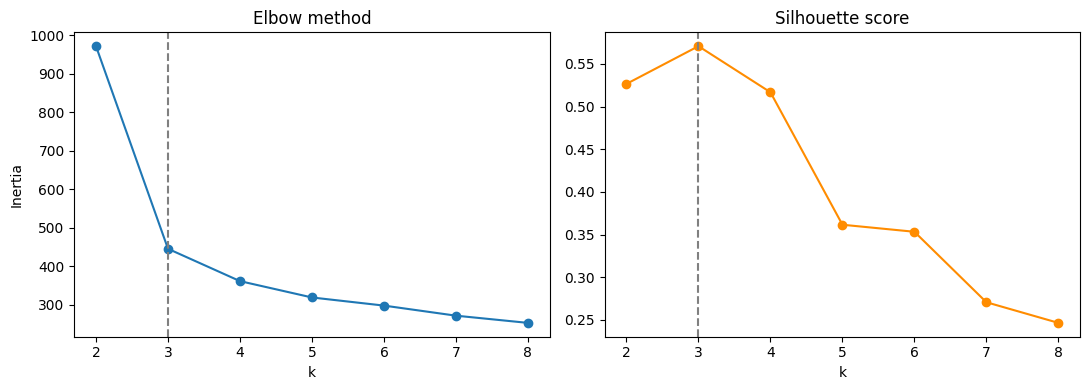

In [3]:
FEATURES = ['orders_per_month','avg_order_value','avg_items_per_order','days_since_last_order','discount_rate']
scaler = StandardScaler().fit(diners[FEATURES])
X = scaler.transform(diners[FEATURES])

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))
print(pd.DataFrame({'k': ks, 'inertia': np.round(inertias,1), 'silhouette': np.round(sils,3)}).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertias, 'o-'); ax[0].set_title('Elbow method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(ks, sils, 'o-', color='darkorange'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
for a in ax: a.axvline(3, ls='--', color='grey')
plt.tight_layout(); plt.show()

**Choice: k = 3.** Inertia falls sharply from k=2→3 (971→445) and flattens afterwards (the elbow), and k=3 has the **highest silhouette score (0.571)**. Both methods agree.

In [4]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
diners['cluster'] = kmeans.labels_
profile = diners.groupby('cluster')[FEATURES + ['age','total_spend','reordered']].mean().round(2)
profile['n_diners'] = diners.cluster.value_counts().sort_index()
profile.T

cluster,0,1,2
orders_per_month,3.63,13.10,9.02
avg_order_value,173.91,42.13,96.67
avg_items_per_order,5.98,1.99,2.98
days_since_last_order,18.13,5.00,11.30
discount_rate,0.31,0.62,0.10
age,40.23,22.33,32.51
total_spend,625.40,554.46,879.88
reordered,0.15,0.98,0.52
n_diners,150.00,200.00,130.00


In [5]:
# Name segments from their profile (robust to cluster-number ordering)
p = profile
fam = p.avg_items_per_order.idxmax()            # biggest baskets
stu = p.discount_rate.idxmax()                   # most discount-driven
pre = ({0,1,2} - {fam, stu}).pop()               # remaining: no discounts, highest lifetime spend
segment_names = {int(fam): 'Families', int(stu): 'Budget Students', int(pre): 'Premium Foodies'}
diners['segment'] = diners.cluster.map(segment_names)
print(segment_names)
orders = orders.merge(diners[['diner_id','segment']], on='diner_id')
for s in segment_names.values():
    print(f'{s:16s}', orders[orders.segment==s].item.value_counts().head(6).to_dict())

{0: 'Families', 1: 'Budget Students', 2: 'Premium Foodies'}
Families         {'dessert': 207, 'pizza': 137, 'biryani': 136, 'raita': 136, 'pasta': 77, 'salad': 64}
Budget Students  {'cola': 1016, 'fries': 788, 'burger': 484, 'wrap': 261}
Premium Foodies  {'salad': 369, 'sushi': 249, 'coffee': 234, 'wine': 147, 'steak': 134, 'green_tea': 131}


### Segment profiles
| Segment | Size | Behaviour | Typical items | Reorder rate |
|---|---|---|---|---|
| **Budget Students** | 200 | Age ~22, orders **~13×/month**, cheapest baskets (**~42 AED**, 2 items), ordered **5 days ago**, uses discounts on **62%** of orders | cola, fries, burger, wrap | **98%** |
| **Premium Foodies** | 130 | Age ~33, ~9 orders/month, ~97 AED for 3 items, almost **no discounts (10%)**, **highest lifetime spend (~880 AED)** | salad, sushi, coffee, wine, steak, green tea | **52%** |
| **Families** | 150 | Age ~40, orders only **~3.6×/month** but the **biggest baskets (~6 items, ~174 AED)**, last order **18 days ago** | dessert, pizza, biryani, raita, pasta | **15%** ⚠️ |

## Task 2 — What is ordered together (Apriori)
One row per `order_id`, one True/False column per item.

In [6]:
def mine_rules(df, min_support=0.05, min_conf=0.3):
    basket = pd.crosstab(df.order_id, df.item).gt(0)          # one-hot baskets
    freq = apriori(basket, min_support=min_support, use_colnames=True)
    r = association_rules(freq, metric='lift', min_threshold=1.0)  # keep lift > 1 only
    r = r[r.confidence >= min_conf].copy()
    r['rule'] = r.antecedents.apply(lambda s: ' + '.join(sorted(s))) + '  →  ' + r.consequents.apply(lambda s: ' + '.join(sorted(s)))
    return r.sort_values(['lift','confidence'], ascending=False)[['rule','support','confidence','lift']].round(3).reset_index(drop=True)

overall = mine_rules(orders, min_support=0.02)
print('Overall rules found:', len(overall))
overall.head(15)

Overall rules found: 101


,rule,support,confidence,lift
0,cola + dessert → garlic_bread,0.021,0.933,30.800
1,cola + pizza → garlic_bread,0.021,0.933,30.800
2,garlic_bread → cola + dessert,0.021,0.700,30.800
3,garlic_bread → cola + pizza,0.021,0.700,30.800
4,green_tea → miso_soup + sushi,0.055,0.824,13.834
5,miso_soup + sushi → green_tea,0.055,0.915,13.834
6,miso_soup → green_tea,0.060,0.915,13.826
7,green_tea → miso_soup,0.060,0.901,13.826
8,green_tea + sushi → miso_soup,0.055,0.900,13.814
9,miso_soup → green_tea + sushi,0.055,0.837,13.814


**Top overall rules (interpretation)**
- **miso soup → green tea** (conf 0.92, lift 13.8): almost everyone who orders miso soup also takes green tea → sell a *Japanese set* (sushi + miso + green tea).
- **raita ↔ biryani** (conf 0.90, lift 13.1): biryani is nearly always ordered with raita → bundle raita as a default add-on to biryani.
- **steak → wine** (conf 0.95, lift 12.8): steak orders come with wine → a *steak & wine dinner* combo.

*Caveat:* overall lifts are very large partly because each of these items is ordered by only one segment — so the per-segment view below is the fairer test.

In [7]:
per_segment = {}
for s in ['Families', 'Budget Students', 'Premium Foodies']:
    sub = orders[orders.segment == s]
    per_segment[s] = mine_rules(sub, min_support=0.05)
    print(f'\n===== {s}  ({sub.order_id.nunique()} baskets, {len(per_segment[s])} rules) =====')
    print(per_segment[s].head(8).to_string(index=False))


===== Families  (304 baskets, 67 rules) =====
                                   rule  support  confidence  lift
cola + dessert + pizza  →  garlic_bread    0.115       0.946 4.793
garlic_bread  →  cola + dessert + pizza    0.115       0.583 4.793
        garlic_bread  →  cola + dessert    0.138       0.700 4.729
          garlic_bread  →  cola + pizza    0.138       0.700 4.729
        cola + dessert  →  garlic_bread    0.138       0.933 4.729
          cola + pizza  →  garlic_bread    0.138       0.933 4.729
                  cola  →  garlic_bread    0.161       0.925 4.684
                  garlic_bread  →  cola    0.161       0.817 4.684



===== Budget Students  (1123 baskets, 7 rules) =====
                 rule  support  confidence  lift
wrap  →  cola + fries    0.191       0.820 1.302
cola + fries  →  wrap    0.191       0.303 1.302
cola + wrap  →  fries    0.191       0.911 1.298
       wrap  →  fries    0.210       0.904 1.289
fries + wrap  →  cola    0.191       0.907 1.002
      burger  →  cola    0.390       0.905 1.000
      cola  →  burger    0.390       0.431 1.000

===== Premium Foodies  (553 baskets, 41 rules) =====
                           rule  support  confidence  lift
miso_soup + sushi  →  green_tea    0.195       0.915 3.864
green_tea  →  miso_soup + sushi    0.195       0.824 3.864
        miso_soup  →  green_tea    0.213       0.915 3.861
        green_tea  →  miso_soup    0.213       0.901 3.861
green_tea + sushi  →  miso_soup    0.195       0.900 3.858
miso_soup  →  green_tea + sushi    0.195       0.837 3.858
         wine  →  salad + steak    0.213       0.803 3.639
         salad + steak  →  w

**Per-segment interpretation**
- **Families:** *pizza + cola + dessert → garlic bread* (conf 0.95, lift 4.8); also *pasta → pizza* (0.94, 2.1) and *biryani ↔ raita* (0.90, 2.0). → A **Family Pizza Night bundle** (pizza + garlic bread + dessert + cola) and a **Biryani feast** (biryani + raita + salad).
- **Premium Foodies:** *miso soup ↔ green tea* (0.92, lift 3.9), *steak → wine* (0.95, 3.6), *pasta → coffee* (0.89, 2.1). → **Sushi set** and **Steak & wine** premium combos — sell on quality, not discounts.
- **Budget Students:** only weak rules — *wrap → fries* (0.90, lift 1.29); *burger → cola* has lift **1.00** (cola is in almost every student order, so it carries no information). → They already buy a fixed "combo" (main + fries + cola); a cheap **wrap meal deal** is the only real cross-sell lever.

**Yes — segments order very differently.** No item overlap between students and the other two groups; families and foodies share only pasta/salad.

## Task 3 — Predict who reorders (Classification)

In [8]:
CLF_FEATURES = FEATURES + ['age', 'total_spend']        # exactly what the dashboard sends
Xc, y = diners[CLF_FEATURES], diners.reordered
X_tr, X_te, y_tr, y_te = train_test_split(Xc, y, test_size=0.25, random_state=42, stratify=y)
baseline = y_te.value_counts(normalize=True).max()
print(f'Train {len(X_tr)} / Test {len(X_te)} | Baseline (always predict "reorder"): {baseline:.3f}')

candidates = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Decision Tree (depth 4)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42)}
rows = []
for name, m in candidates.items():
    m.fit(X_tr, y_tr)
    rows.append([name, accuracy_score(y_te, m.predict(X_te)), cross_val_score(m, Xc, y, cv=5).mean()])
pd.DataFrame(rows, columns=['model','test_accuracy','5-fold CV accuracy']).round(3)

Train 360 / Test 120 | Baseline (always predict "reorder"): 0.600


,model,test_accuracy,5-fold CV accuracy
0,Logistic Regression,0.858,0.860
1,Decision Tree (depth 4),0.842,0.821
2,Random Forest,0.867,0.840


Logistic Regression has the best cross-validated accuracy (most reliable estimate), is interpretable, and — wrapped in a pipeline with its own scaler — takes raw inputs straight from the dashboard. **Chosen model.**

Accuracy: 0.858  vs baseline 0.600

               precision    recall  f1-score   support

  churned (0)       0.82      0.83      0.82        48
reordered (1)       0.89      0.88      0.88        72

     accuracy                           0.86       120
    macro avg       0.85      0.85      0.85       120
 weighted avg       0.86      0.86      0.86       120



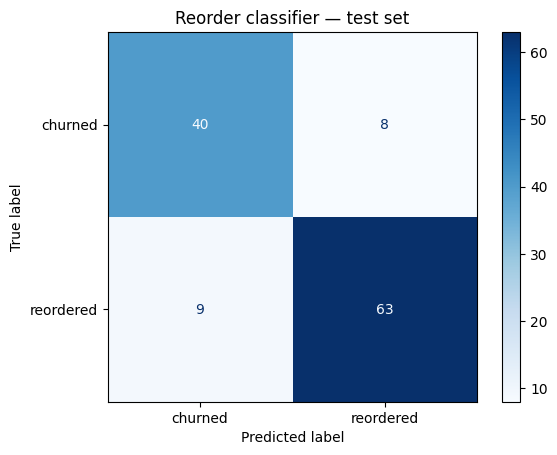

days_since_last_order   -1.63
avg_order_value         -0.76
total_spend             -0.03
age                      0.08
avg_items_per_order      0.39
discount_rate            0.78
orders_per_month         0.86
dtype: float64


In [9]:
clf = candidates['Logistic Regression']
pred = clf.predict(X_te)
print(f'Accuracy: {accuracy_score(y_te, pred):.3f}  vs baseline {baseline:.3f}\n')
print(classification_report(y_te, pred, target_names=['churned (0)', 'reordered (1)']))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=['churned', 'reordered']).plot(cmap='Blues')
plt.title('Reorder classifier — test set'); plt.show()
print(pd.Series(clf[-1].coef_[0], index=CLF_FEATURES).sort_values().round(2))

**Reading the confusion matrix (test set, 120 diners):** 40 churners correctly flagged, 63 loyal diners correctly identified; **8 churners were missed** (predicted to reorder) and **9 loyal diners were false alarms**.

**Accuracy 85.8% vs 60% baseline** — the model clearly beats always guessing "reorder".

**Which mistake costs more?** Missing a real churner — that customer is lost along with all future orders. A false alarm only costs a voucher sent to someone who would have stayed. So QuickBite should favour **catching churners**. Recency is the strongest driver (more days since last order → churn), followed by low frequency and high order value.

In [10]:
# Cost-aware view: demand more confidence before calling someone 'safe'
proba = clf.predict_proba(X_te)[:, 1]
for t in [0.5, 0.6, 0.7]:
    tn, fp, fn, tp = confusion_matrix(y_te, (proba >= t).astype(int)).ravel()
    print(f'threshold {t}: accuracy {(tn+tp)/len(y_te):.3f} | churners caught {tn}/{tn+fp} | loyal diners wrongly flagged {fn}')

threshold 0.5: accuracy 0.858 | churners caught 40/48 | loyal diners wrongly flagged 9
threshold 0.6: accuracy 0.858 | churners caught 44/48 | loyal diners wrongly flagged 13
threshold 0.7: accuracy 0.850 | churners caught 47/48 | loyal diners wrongly flagged 17


Raising the threshold to **0.6** catches **44/48 churners instead of 40** at the same 85.8% accuracy — a better operating point for a retention campaign.

## Task 4 — Save models for the dashboard

In [11]:
# Refit the final classifier on all diners for deployment
clf.fit(Xc, y)
reco = {s: orders[orders.segment == s].item.value_counts().head(5).index.tolist() for s in segment_names.values()}
bundle = {'scaler': scaler, 'kmeans': kmeans, 'segment_names': segment_names,
          'clf': clf, 'features': FEATURES, 'reco': reco}
joblib.dump(bundle, 'food_models.joblib')
print('Saved food_models.joblib'); reco

Saved food_models.joblib


{'Families': ['dessert', 'pizza', 'biryani', 'raita', 'pasta'],
 'Budget Students': ['cola', 'fries', 'burger', 'wrap'],
 'Premium Foodies': ['salad', 'sushi', 'coffee', 'wine', 'steak']}

In [12]:
# Test with the same logic app.py uses
M = joblib.load('food_models.joblib')
def analyse(profile):
    row = pd.DataFrame([profile])
    seg = M['segment_names'][int(M['kmeans'].predict(M['scaler'].transform(row[M['features']]))[0])]
    p = M['clf'].predict_proba(row[M['features'] + ['age','total_spend']])[0][1]
    return seg, 'Yes' if p >= 0.5 else 'At risk', round(p, 2), M['reco'][seg]
tests = {
 'Student':  dict(age=21, orders_per_month=14, avg_order_value=40,  avg_items_per_order=2, days_since_last_order=3,  discount_rate=0.7,  total_spend=550),
 'Family':   dict(age=42, orders_per_month=3,  avg_order_value=180, avg_items_per_order=6, days_since_last_order=20, discount_rate=0.3,  total_spend=600),
 'Foodie':   dict(age=33, orders_per_month=9,  avg_order_value=100, avg_items_per_order=3, days_since_last_order=8,  discount_rate=0.05, total_spend=900),
 'App default': dict(age=28, orders_per_month=8, avg_order_value=90, avg_items_per_order=3, days_since_last_order=10, discount_rate=0.3, total_spend=800)}
pd.DataFrame({k: analyse(v) for k, v in tests.items()}, index=['segment','reorder?','probability','recommended']).T

,segment,reorder?,probability,recommended
Student,Budget Students,Yes,1.0,"[cola, fries, burger, wrap]"
Family,Families,At risk,0.04,"[dessert, pizza, biryani, raita, pasta]"
Foodie,Premium Foodies,Yes,0.66,"[salad, sushi, coffee, wine, steak]"
App default,Premium Foodies,Yes,0.72,"[salad, sushi, coffee, wine, steak]"


Then in a terminal, in this folder: `streamlit run app.py`

## Business takeaway
**Families are the priority:** they spend the most per order (~174 AED) but only 15% reorder, so they are where retention money pays back most. Promote a **Family Pizza Night bundle (pizza + garlic bread + dessert + cola)** and a **biryani + raita** combo to them, and a **sushi + miso + green tea** set / **steak & wine** combo to Premium Foodies, who don't need discounts. Budget Students are already loyal (98% reorder) — don't spend extra discount budget on them. Run the reorder model weekly, send win-back offers to every diner it scores below ~60% reorder probability, and prioritise those with high order value.